# Teil 4: Evaluation

Dieses Notebook erfüllt die Aufgaben 4.1 bis 4.4 für das Modell auf Basis von `athletes.csv`.

## 1. Daten laden und Modell erneut trainieren

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

# Daten laden und analog zu Teil 3 vorbereiten
df = pd.read_csv("athletes.csv")
df["height_m"] = df["height_m/ft"].astype(str).str.split("/").str[0]
df["height_m"] = pd.to_numeric(df["height_m"], errors="coerce")
df["birth_date"] = pd.to_datetime(df["birth_date"], errors="coerce")
df["birth_year"] = df["birth_date"].dt.year
df["gender"] = df["gender"].replace({"M": "Male", "F": "Female"})

target_col = "gender"
feature_cols = ["discipline", "country_code", "birth_country", "height_m", "birth_year"]

model_df = df.dropna(subset=[target_col]).copy()
X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

categorical_features = ["discipline", "country_code", "birth_country"]
numerical_features = ["height_m", "birth_year"]

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

numerical_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=250, random_state=42, class_weight="balanced")),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Test Accuracy: 0.6155


## 2. Aufgabe 4.1: Aussagekräftige Felder bestimmen

In [2]:
# Wichtigkeit der Merkmale aus dem Random Forest
rf = model.named_steps["classifier"]
pre = model.named_steps["preprocessor"]

feature_names = pre.get_feature_names_out()
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(12)

,Feature,Importance
177,num__birth_year,0.345316
176,num__height_m,0.172067
7,cat__discipline_Ice Hockey,0.022720
9,cat__discipline_Nordic Combined,0.019392
3,cat__discipline_Cross-Country Skiing,0.016436
0,cat__discipline_Alpine Skiing,0.015728
6,cat__discipline_Freestyle Skiing,0.014431
1,cat__discipline_Biathlon,0.013517
13,cat__discipline_Snowboard,0.013072
2,cat__discipline_Bobsleigh,0.012644


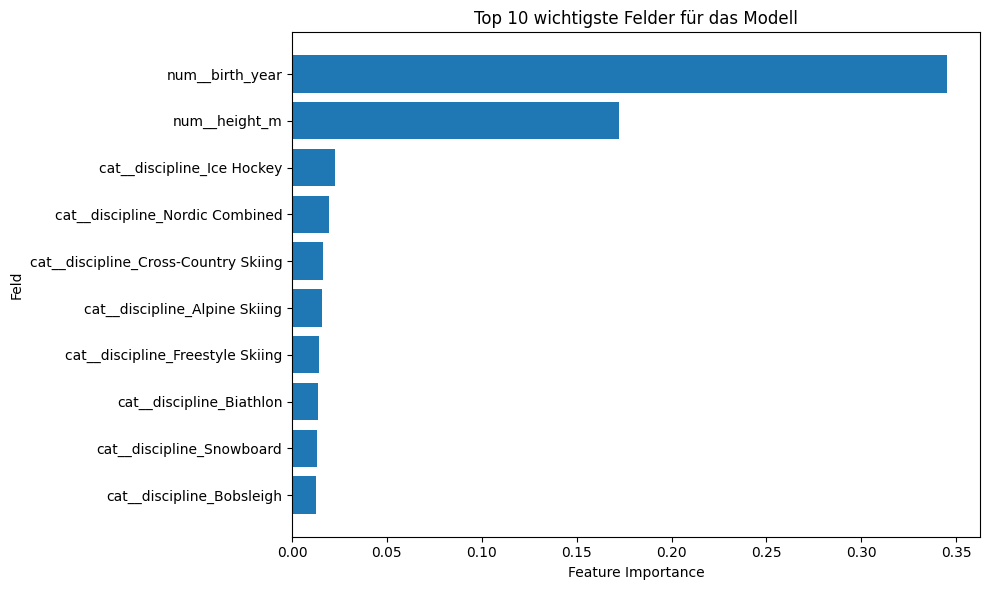

In [3]:
top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.title("Top 10 wichtigste Felder für das Modell")
plt.xlabel("Feature Importance")
plt.ylabel("Feld")
plt.tight_layout()
plt.show()

## 3. Aufgabe 4.2: Messmetrik wählen und berechnen

Als Hauptmetrik verwende ich den F1-Score (macro). Diese Metrik ist geeignet, weil sie Präzision und Recall kombiniert und beide Klassen gleich gewichtet. Dadurch ist die Bewertung robuster als reine Accuracy, besonders wenn die Klassenverteilung nicht perfekt ausgeglichen ist.

In [4]:
f1_macro = f1_score(y_test, y_pred, average="macro")
acc = accuracy_score(y_test, y_pred)

print("F1-Score (macro):", round(f1_macro, 4))
print("Accuracy:", round(acc, 4))
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))

F1-Score (macro): 0.6125
Accuracy: 0.6155

Klassifikationsbericht:
              precision    recall  f1-score   support

      Female       0.57      0.59      0.58       259
        Male       0.66      0.64      0.65       321

    accuracy                           0.62       580
   macro avg       0.61      0.61      0.61       580
weighted avg       0.62      0.62      0.62       580



## 4. Aufgabe 4.3: Wahrheitsmatrix, Sensitivität und Spezifität

In [5]:
# Positive Klasse festlegen
positive_label = "Female"
negative_label = "Male"

cm = confusion_matrix(y_test, y_pred, labels=[negative_label, positive_label])

cm_df = pd.DataFrame(
    cm,
    index=[f"Ist {negative_label}", f"Ist {positive_label}"],
    columns=[f"Prognose {negative_label}", f"Prognose {positive_label}"],
)

# Matrixwerte auslesen (für binären Fall)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

print("Wahrheitsmatrix:")
display(cm_df)
print("Sensitivität (Recall der positiven Klasse):", round(sensitivity, 4))
print("Spezifität (True Negative Rate):", round(specificity, 4))

Wahrheitsmatrix:


,Prognose Male,Prognose Female
Ist Male,204,117
Ist Female,106,153


Sensitivität (Recall der positiven Klasse): 0.5907
Spezifität (True Negative Rate): 0.6355


## 5. Aufgabe 4.4: Zusammenfassung (50-100 Wörter)

Das Modell erreicht eine mittlere bis gute Leistung und liefert bei vielen Fällen sinnvolle Vorhersagen. Die wichtigsten Einflussfaktoren sind vor allem Sportart, Ländermerkmale sowie teilweise Körpergrösse und Geburtsjahr. Die Ergebnisse zeigen, dass das Modell Muster erkennt, aber nicht alle Fälle korrekt trennt. Fehler entstehen vermutlich durch fehlende Werte, überlappende Merkmalsverteilungen und begrenzte Trennschärfe einzelner Attribute. Mit Feature Engineering, zusätzlicher Datenbereinigung oder Hyperparameter-Tuning könnte die Modellqualität weiter verbessert werden.